In [1]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math

In [2]:
path_google = 'G:/Shared drives/'
def make_single_model(params):

    teff  = params["teff"]
    logg  = params["logg"]
    vsini = params["vsini"]
    vrad  = params["vrad"]
    vturb = params["vturb"]

    # Load TLUSTY model
    model_name = vp.tlusty.galB_path_name.format(
        "vis",
        teff,
        logg,
        str(vturb)
    )

    model = vp.tlusty.read_norm(
        path_google + model_name
    )

    # Apply RV shift + rotational broadening
    model = dopplershift_rotate(
        model,
        vrad,
        vsini
    )

    model_label = (
        rf"$T_{{\rm eff}}={teff}$ K, "
        rf"$\log g={logg/100:.2f}$, "
        rf"$v\sin i={vsini}$ km/s, "
        rf"$v_r={vrad}$ km/s"
    )

    return model, model_label
def make_binary_model_O(p):
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_B(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label

def dopplershift_rotate(spectrum, dopplershift, vsini):
    shifted_spectrum = spectrum.doppler_shift(dopplershift)
    convolved_spectrum = shifted_spectrum.convolveRot(vsini, 0.5)
    return convolved_spectrum


In [3]:
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")
name = "hd218440_E_1734576pnm_rn.s"

spec = pol.read_spectrum(obs_folder / f"{name}")
# spec = pol.read_spectrum(
#     r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero/hd139365_H_55706.21013097pn_rn.s")
path_google = 'G:\Shared drives\\'


In [ ]:
windows = [(400,412), (432,440), (445,455), (467,473), (485,495)]


lines_H = [
    (410.1, 'Hδ 4101'),
    (434.0, "Hγ 4340"),
        (486.1, "Hβ, 4861")]
lines_He = [
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
]
vrad = 50
vsini = 20

fig, ax = plt.subplots(len(windows), 1, figsize=(10, 3 * len(windows)))
for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=0.6, label="Observation")
    # ax[i].plot(joint.wl/10, joint.specI,
            #    lw=0.8, label=synthetic_spec_1+'\n'+synthetic_spec_2)
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.15)
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red',ls='--',lw=0.8)
            ax[i].text(wl,1.1,label,color='red', ha='center',va='bottom',fontsize=8)
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.8)
            ax[i].text(wl,1.1,label,color='purple', ha='center',va='bottom',fontsize=8)
    ax[i].legend()
ax[-1].set_xlabel("Wavelength (nm)")
fig.suptitle(f"{name}")
# fig.suptitle(f"{synthetic_spec_1}: vrad = {vrad1}, vsini = {vsini1} {synthetic_spec_2}: vrad = {vrad2}, vsini = {vsini2},R2/R1 = {R2R1}")
plt.tight_layout()
plt.show()


In [ ]:
# Teff — match the He I/He II ionization balance (e.g., 4200, 4471, 4541).
# log g — Balmer wings (Hδ, Hγ, Hβ). higher log g, broader wings
# vsini — match the widths of the helium and metal lines.

params = {"teff1": 18000, "logg1": 325, "vsini1": 100, "vrad1":-10,"R2R1": 1.0,"vturb": 2}
# ---------------- Load TLUSTY models ----------------
file_name_1 = f"G{params['teff1']}g{params['logg1']}v{params['vturb']}.vis"

my_model_name1 = vp.tlusty.galB_path_name.format(
    "vis",
    params["teff1"],
    params["logg1"],
    str(params["vturb"])
)



In [ ]:
model = vp.tlusty.read_norm(path_google + my_model_name1)

# Apply radial velocity shift and rotational broadening
model = dopplershift_rotate(
    model,
    params["vrad1"],
    params["vsini1"]
)

# ---------------- Plot ----------------
fig, ax = plt.subplots(
    len(windows),
    1,
    figsize=(12, 2.8 * len(windows)),
    sharey=True
)

for i, (xmin, xmax) in enumerate(windows):

    ax[i].plot(spec.wl,spec.specI,color="grey",lw=0.5, label="Obs")

    ax[i].plot(model.wl / 10,model.specI, color="red",lw=0.8,label="Model")

    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Put legend inside each panel
    ax[i].legend(loc="upper right",fontsize=8,frameon=False)

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="red", ls="--", lw=0.7)
            ax[i].text(
                wl + 0.5,
                0.70,
                label,
                color="red",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top"
            )

    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="purple", ls="--", lw=0.7)
            ax[i].text(
                wl + 0.5,
                0.70,
                label,
                color="purple",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top"
            )

ax[-1].set_xlabel("Wavelength (nm)")

title = (f"{name}\n"
    f"Teff={params['teff1']} K, logg={params['logg1']} vsini={params['vsini1']} km/s, vrad={params['vrad1']} km/s\n"
)

fig.suptitle(title, fontsize=11, y=0.92)



plt.show()



In [26]:
base_params = {"teff": 20000, "logg":375,"vsini": 30,"vrad":25,"R2R1":0.4,"vturb": 2,}

# Teff  — match He I / He II ionization balance
# log g — Balmer wings (higher log g -> broader wings)
# vsini — widths of helium and metal lines
# vrad  — positions of the spectral lines

trial_updates = [

    ("base", {}),

    # Teff trials
    # ("Teff=30k", {"teff": 30000}),
    # ("Teff=28k", {"teff": 28000}),
    # ("Teff=29k", {"teff": 29000}),
    # ("Teff=26k", {"teff": 25000}),

    # ("Teff=15k", {"teff": 15000}),
    # ("Teff=25k", {"teff": 25000}),
    # log g trials
    # ("logg=300", {"logg": 375}),
    # ("logg=350", {"logg": 325}),

    # vsini trials
    # ("vsini=40",{"vsini":40}),
    # ("vsini=20",{"vsini":20})

    # ("vsini=80,logg=325",  {"vsini": 80,"logg":325}),
    # ("vsini=80,logg=350",  {"vsini": 80,"logg":350}),

    # ("vsini=120,logg=325",  {"vsini": 120,"logg":325}),
    # ("vsini=120,logg=350",  {"vsini": 120,"logg":350}),

    # ("vsini=60,logg=375",{"vsini":60,"logg":375}),
    # ("vsini=80,logg=325",  {"vsini": 80,"logg":325}),
    # ("vsini=80,logg=375",  {"vsini": 80,"logg":375}),
    # ("vsini=40", {"vsini": 40,"vrad":20,"logg":350}),
    # vrad trials
    # ("vrad=25",  {"vrad": 25}),
    # ("vrad=30", {"vrad": 30}),

    # Can also change multiple parameters
    # ("T18k_g375", {
    #     "teff": 18000,
    #     "logg": 375
    # }),
]

# Build a full parameter dictionary for every trial
trials = []

for name, updates in trial_updates:
    p = base_params.copy()
    p.update(updates)
    trials.append((name, p))

models = []

for name, params in trials:
    model, model_label = make_single_model(params)
    models.append((name, params, model))


print(f"Generated {len(models)} trial models:")
for name, params, model in models:
    print(f"  {name}: {params}")

Generated 1 trial models:
  base: {'teff': 20000, 'logg': 375, 'vsini': 30, 'vrad': 25, 'R2R1': 0.4, 'vturb': 2}


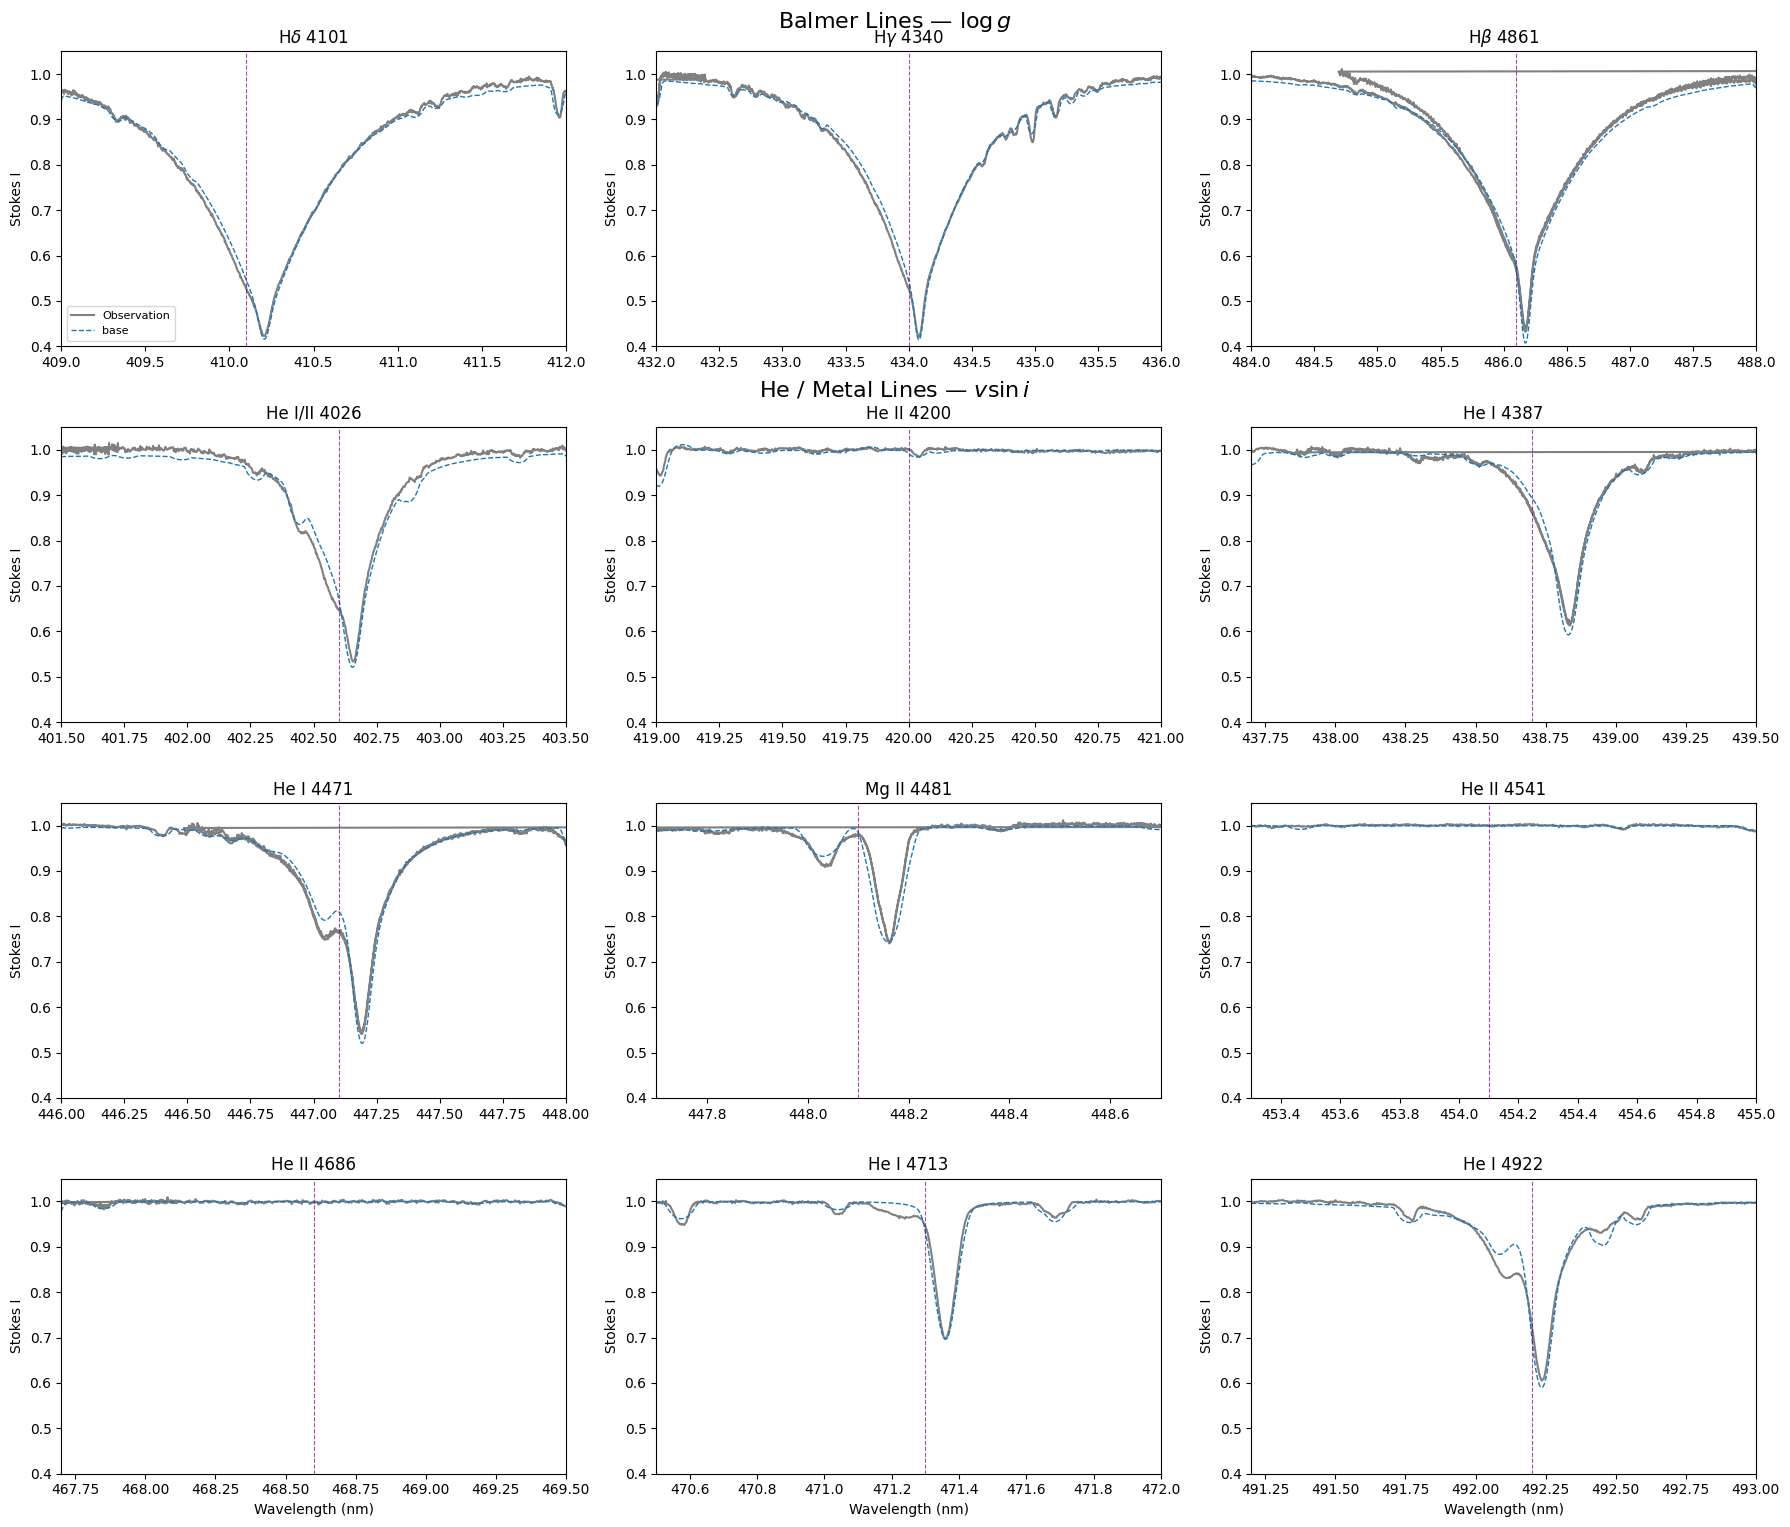

In [27]:
# =========================
# LINE DIAGNOSTIC PLOT
# =========================

H_lines = [(409,412,410.1,r"H$\delta$ 4101"), (432,436,434.0,r"H$\gamma$ 4340"),
           (484,488,486.1,r"H$\beta$ 4861")]

He_lines = [(401.5,403.5,402.6,"He I/II 4026"), (419,421,420.0,"He II 4200"),
            (437.7,439.5,438.7,"He I 4387"), (446,448,447.1,"He I 4471"),
            (447.7,448.7,448.1,"Mg II 4481"), (453.3,455,454.1,"He II 4541"),
            (467.7,469.5,468.6,"He II 4686"), (470.5,472,471.3,"He I 4713"),
            (491.2,493,492.2,"He I 4922")]

fig, ax = plt.subplots(4,3,figsize=(18,16))
all_lines = H_lines + He_lines

for a, (xmin,xmax,wl,line) in zip(ax.flat,all_lines):
    a.plot(spec.wl,spec.specI,color="0.5",lw=1.5,label="Observation")
    for trial_name,params,model in models:
        a.plot(model.wl/10,model.specI,lw=1,ls="--",label=trial_name)

    a.axvline(wl,color="purple",ls="--",lw=0.8,alpha=0.7)
    a.set_xlim(xmin,xmax); a.set_ylim(0.4,1.05)
    a.set_title(line); a.set_ylabel("Stokes I")

for a in ax[-1]: a.set_xlabel("Wavelength (nm)")

ax[0,0].legend(fontsize=8)
fig.text(0.5,0.94,r"Balmer Lines — $\log g$",ha="center",fontsize=16)
fig.text(0.5,0.71,r"He / Metal Lines — $v\sin i$",ha="center",fontsize=16)

plt.tight_layout(rect=[0,0,1,0.95],h_pad=2.5)
plt.show()